In [1]:
import pandas as pd

# --- STEP 1: Nigerian-Specific Emission Factors ---
factors = [
    {"activity": "water_supply", "unit": "m3", "emission_factor": 0.344},
    {"activity": "wastewater_unmanaged", "unit": "m3", "emission_factor": 0.708},
    {"activity": "wastewater_centralized", "unit": "m3", "emission_factor": 0.272},
]
df_factors = pd.DataFrame(factors)
df_factors.to_csv("water_emission_factors.csv", index=False)
print(" water_emission_factors.csv created")
print(df_factors, "\n")

# --- STEP 2: Generate Synthetic Water Data ---
businesses = [
    {"business_id": "B0001", "business_type": "Bakery", "treatment_type": "unmanaged"},
    {"business_id": "B0002", "business_type": "Restaurant", "treatment_type": "centralized"},
    {"business_id": "B0003", "business_type": "Supermarket", "treatment_type": "unmanaged"},
]

months = pd.date_range("2024-01-01", "2024-12-01", freq="MS").strftime("%Y-%m").tolist()

data = []
for b in businesses:
    for m in months:
        # Generate synthetic water usage ranges
        if b["business_type"] == "Bakery":
            water = 100 + (hash(m+b["business_id"]) % 50)   # 100–150 m3
            wastewater = water * 0.7                        # 70% of water
        elif b["business_type"] == "Restaurant":
            water = 250 + (hash(m+b["business_id"]) % 100)  # 250–350 m3
            wastewater = water * 0.67
        elif b["business_type"] == "Supermarket":
            water = 400 + (hash(m+b["business_id"]) % 150)  # 400–550 m3
            wastewater = water * 0.75

        # Append records
        data.append({
            "business_id": b["business_id"], "business_type": b["business_type"],
            "date": m, "treatment_type": b["treatment_type"],
            "flow_type": "water_consumed_m3", "volume_m3": water
        })
        data.append({
            "business_id": b["business_id"], "business_type": b["business_type"],
            "date": m, "treatment_type": b["treatment_type"],
            "flow_type": "wastewater_m3", "volume_m3": wastewater
        })

df_water = pd.DataFrame(data)
df_water.to_csv("water.csv", index=False)
print("water.csv created with", len(df_water), "rows")
print(df_water.head(), "\n")

# --- STEP 3: Map Flow Type -> Activity ---
def map_activity(row):
    if row["flow_type"] == "water_consumed_m3":
        return "water_supply"
    elif row["flow_type"] == "wastewater_m3":
        return "wastewater_" + row["treatment_type"]
    return None

df_water["activity"] = df_water.apply(map_activity, axis=1)

# --- STEP 4: Merge with Emission Factors ---
df_summary = df_water.merge(df_factors, how="left", on="activity")

# Calculate emissions
df_summary["emissions_kgCO2e"] = df_summary["volume_m3"] * df_summary["emission_factor"]

# --- STEP 5: Save Final Summary ---
df_summary.to_csv("water_emissions_summary.csv", index=False)
print(" water_emissions_summary.csv created with", len(df_summary), "rows")
print(df_summary.head(10))


 water_emission_factors.csv created
                 activity unit  emission_factor
0            water_supply   m3            0.344
1    wastewater_unmanaged   m3            0.708
2  wastewater_centralized   m3            0.272 

water.csv created with 72 rows
  business_id business_type     date treatment_type          flow_type  \
0       B0001        Bakery  2024-01      unmanaged  water_consumed_m3   
1       B0001        Bakery  2024-01      unmanaged      wastewater_m3   
2       B0001        Bakery  2024-02      unmanaged  water_consumed_m3   
3       B0001        Bakery  2024-02      unmanaged      wastewater_m3   
4       B0001        Bakery  2024-03      unmanaged  water_consumed_m3   

   volume_m3  
0      130.0  
1       91.0  
2      122.0  
3       85.4  
4      140.0   

 water_emissions_summary.csv created with 72 rows
  business_id business_type     date treatment_type          flow_type  \
0       B0001        Bakery  2024-01      unmanaged  water_consumed_m3   
1   

In [3]:
df_summary.shape

(72, 10)

In [4]:
df_summary.head(10)

,business_id,business_type,date,treatment_type,flow_type,volume_m3,activity,unit,emission_factor,emissions_kgCO2e
0,B0001,Bakery,2024-01,unmanaged,water_consumed_m3,130.0,water_supply,m3,0.344,44.7200
1,B0001,Bakery,2024-01,unmanaged,wastewater_m3,91.0,wastewater_unmanaged,m3,0.708,64.4280
2,B0001,Bakery,2024-02,unmanaged,water_consumed_m3,122.0,water_supply,m3,0.344,41.9680
3,B0001,Bakery,2024-02,unmanaged,wastewater_m3,85.4,wastewater_unmanaged,m3,0.708,60.4632
4,B0001,Bakery,2024-03,unmanaged,water_consumed_m3,140.0,water_supply,m3,0.344,48.1600
5,B0001,Bakery,2024-03,unmanaged,wastewater_m3,98.0,wastewater_unmanaged,m3,0.708,69.3840
6,B0001,Bakery,2024-04,unmanaged,water_consumed_m3,130.0,water_supply,m3,0.344,44.7200
7,B0001,Bakery,2024-04,unmanaged,wastewater_m3,91.0,wastewater_unmanaged,m3,0.708,64.4280
8,B0001,Bakery,2024-05,unmanaged,water_consumed_m3,144.0,water_supply,m3,0.344,49.5360
9,B0001,Bakery,2024-05,unmanaged,wastewater_m3,100.8,wastewater_unmanaged,m3,0.708,71.3664


In [6]:
df_summary["treatment_type"].value_counts()

,count
treatment_type,
unmanaged,48
centralized,24


Treatment Type

This describes how wastewater is handled:

Unmanaged → wastewater is dumped untreated (e.g., septic tanks, soakaways, direct discharge).

Centralized → wastewater goes into a treatment plant (municipal/industrial), where emissions are lower because methane is captured.

Activity

This is the emission activity category that links to emission factors:

Water supply → emissions from pumping, treating, and delivering clean water.

Wastewater_unmanaged → emissions from untreated wastewater (high methane).

Wastewater_centralized → emissions from treated wastewater (lower methane).

## EXPLORATORY DATA ANALYSIS

Text(0, 0.5, 'Business Type')

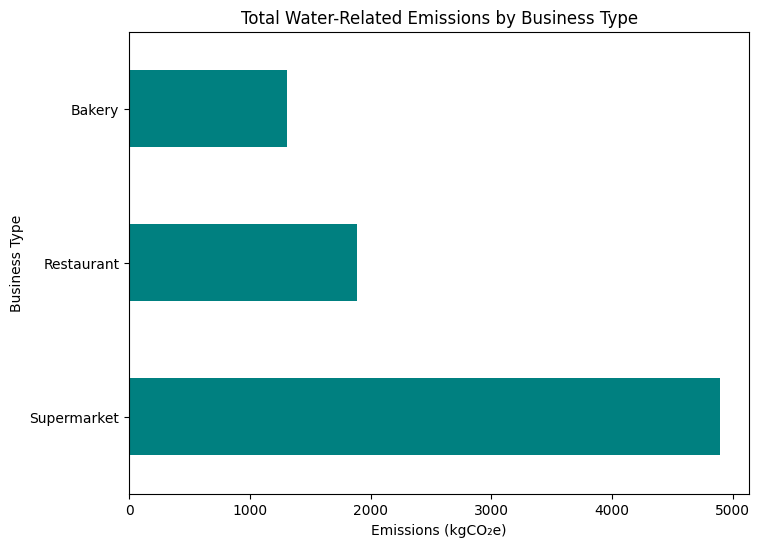

In [11]:
# --- 1. Total emissions by business type ---
import matplotlib.pyplot as plt

business_emissions = df_summary.groupby("business_type")["emissions_kgCO2e"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
business_emissions.plot(kind="barh", color="teal")
plt.title("Total Water-Related Emissions by Business Type")
plt.xlabel("Emissions (kgCO₂e)")
plt.ylabel("Business Type")

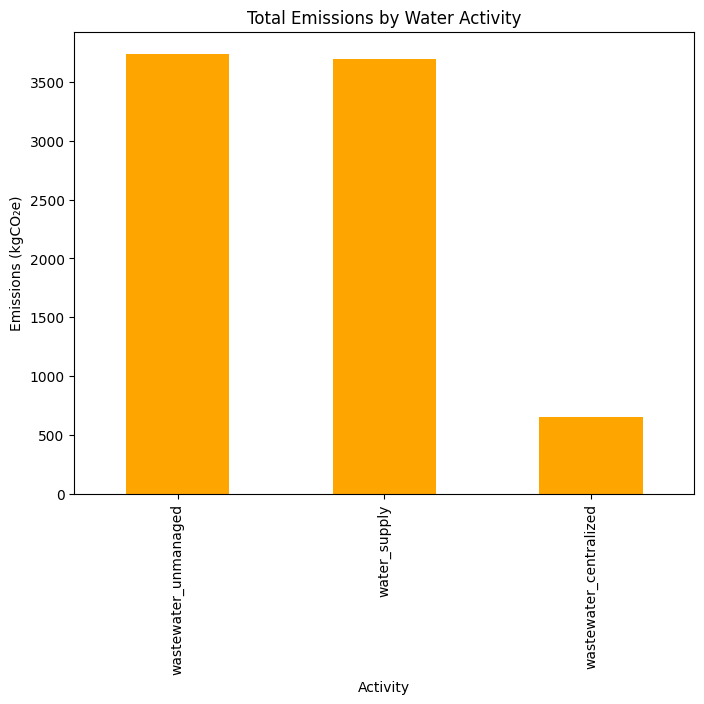

In [13]:
activity_emissions = df_summary.groupby("activity")["emissions_kgCO2e"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
activity_emissions.plot(kind="bar", color="orange")
plt.title("Total Emissions by Water Activity")
plt.ylabel("Emissions (kgCO₂e)")
plt.xlabel("Activity")
plt.show()


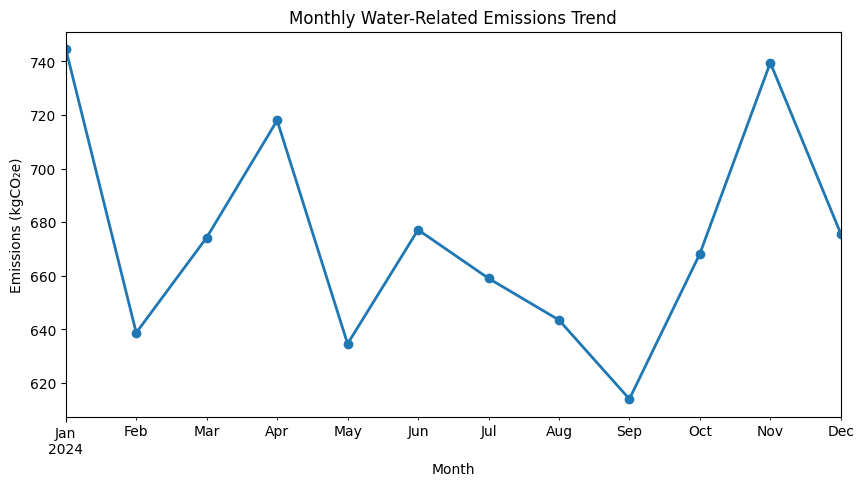

In [17]:
df_summary["date"] = pd.to_datetime(df_summary["date"])
monthly_emissions = df_summary.groupby(df_summary["date"].dt.to_period("M"))["emissions_kgCO2e"].sum()

plt.figure(figsize=(10,5))
monthly_emissions.plot(marker="o", linewidth=2)
plt.title("Monthly Water-Related Emissions Trend")
plt.xlabel("Month")
plt.ylabel("Emissions (kgCO₂e)")
plt.show()


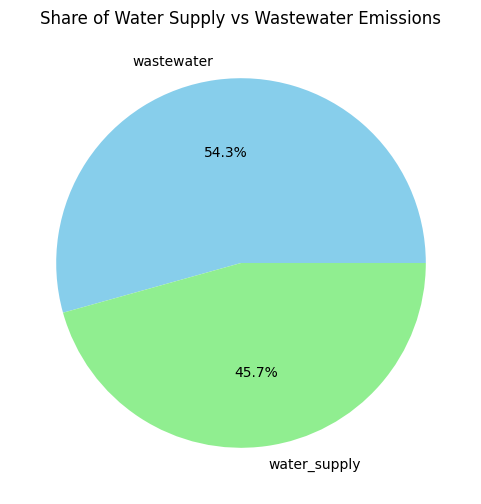

In [24]:
df_summary["category"] = df_summary["activity"].apply(lambda x: "water_supply" if "supply" in x else "wastewater")

category_emissions = df_summary.groupby("category")["emissions_kgCO2e"].sum()

plt.figure(figsize=(6,6))
category_emissions.plot(kind="pie", autopct="%1.1f%%", colors=["skyblue","lightgreen"])
plt.title("Share of Water Supply vs Wastewater Emissions")
plt.ylabel("")
plt.show()


In [27]:
df_summary.to_csv("water_emissions_summary.csv", index = False)

from google.colab import files
files.download("water_emissions_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>